# Этап 5. Сравнительный анализ моделей

В этом ноутбуке объединяются результаты предыдущих этапов и проводится общий сравнительный анализ моделей:

- одиночное дерево решений;
- BaggingRegressor;
- RandomForestRegressor;
- XGBRegressor.

Сравнение выполняется по метрикам качества, скорости инференса, графикам ошибок, анализу подгрупп, важности признаков и SHAP-интерпретации.

## Импорт библиотек и загрузка данных

Используем уже обработанные выборки и сохраненные модели из предыдущих этапов.  
Все метрики считаются в исходной шкале `charges`, поэтому предсказания переводятся обратно через `expm1`.

In [1]:
from pathlib import Path
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

warnings.filterwarnings('ignore')

cwd = Path.cwd()

if (cwd / 'data' / 'processed').exists():
    project_dir = cwd
elif (cwd.parent / 'data' / 'processed').exists():
    project_dir = cwd.parent
else:
    project_dir = Path('..')

processed_dir = project_dir / 'data' / 'processed'
models_dir = project_dir / 'models'
reports_dir = project_dir / 'reports'
figures_dir = reports_dir / 'figures'

figures_dir.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(processed_dir / 'train_one_hot_encoded.csv')
val_df = pd.read_csv(processed_dir / 'validation_one_hot_encoded.csv')
test_df = pd.read_csv(processed_dir / 'test_one_hot_encoded.csv')

target_col = 'charges'
original_target_col = 'charges_original'
feature_cols = [col for col in train_df.columns if col not in [target_col, original_target_col]]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_val = val_df[feature_cols]
y_val = val_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]
y_test_original = test_df[original_target_col]

models = {
    'Одиночное дерево': joblib.load(models_dir / 'decision_tree_gridsearch_model.pkl'),
    'Bagging': joblib.load(models_dir / 'bagging_gridsearch_model.pkl'),
    'Random Forest': joblib.load(models_dir / 'random_forest_gridsearch_model.pkl'),
    'XGBoost': joblib.load(models_dir / 'xgboost_randomized_search_model.pkl')
}

print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)
print('Модели загружены:', list(models.keys()))

Train: (801, 8)
Validation: (268, 8)
Test: (268, 8)
Модели загружены: ['Одиночное дерево', 'Bagging', 'Random Forest', 'XGBoost']


## Общие функции для расчета метрик

Модели обучались на логарифмированной целевой переменной, поэтому для честного сравнения переводим `y_true` и `y_pred` в исходную шкалу.

In [2]:
def inverse_target(values):
    return np.expm1(values)


def calculate_metrics(y_true_log, y_pred_log):
    y_true = inverse_target(y_true_log)
    y_pred = inverse_target(y_pred_log)
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred)
    }


def predict_on_test(model):
    return model.predict(X_test)

## Сводная таблица метрик

Сравним модели по трем основным метрикам:

- `R²`: чем выше, тем лучше;
- `MAE`: средняя абсолютная ошибка;
- `RMSE`: сильнее штрафует крупные ошибки.

In [3]:
prediction_results = {}
metrics_rows = []

for model_name, model in models.items():
    y_pred = predict_on_test(model)
    prediction_results[model_name] = y_pred
    row = {'Модель': model_name}
    row.update(calculate_metrics(y_test, y_pred))
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).sort_values(by='R2', ascending=False)
metrics_df.to_csv(reports_dir / 'comparison_metrics_table.csv', index=False, encoding='utf-8')
metrics_df

,Модель,R2,MAE,RMSE
3,XGBoost,0.857913,1885.829558,4300.092637
2,Random Forest,0.848514,1964.758602,4440.047761
1,Bagging,0.847519,2010.778925,4454.604696
0,Одиночное дерево,0.839900,1723.630835,4564.536814


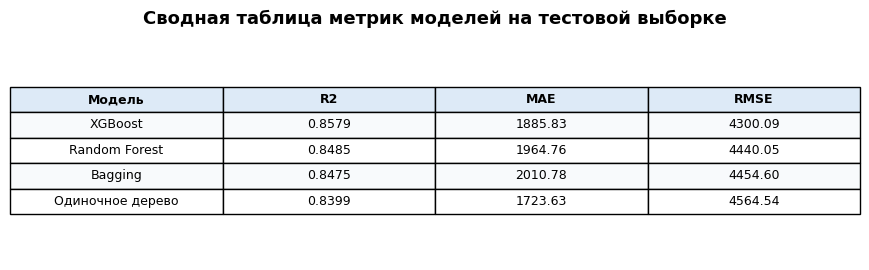

In [4]:
fig, ax = plt.subplots(figsize=(8.8, 2.8))
ax.axis('off')

table_data = metrics_df.copy()
table_data['R2'] = table_data['R2'].map(lambda value: f'{value:.4f}')
table_data['MAE'] = table_data['MAE'].map(lambda value: f'{value:.2f}')
table_data['RMSE'] = table_data['RMSE'].map(lambda value: f'{value:.2f}')

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#DDEAF7')
    else:
        cell.set_facecolor('#F8FAFC' if row % 2 else '#FFFFFF')

plt.title('Сводная таблица метрик моделей на тестовой выборке', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_metrics_table.png', dpi=200, bbox_inches='tight')
plt.show()

## Графическое сравнение метрик

Построим отдельные графики для `R²`, `MAE` и `RMSE`, чтобы визуально увидеть разницу между моделями.

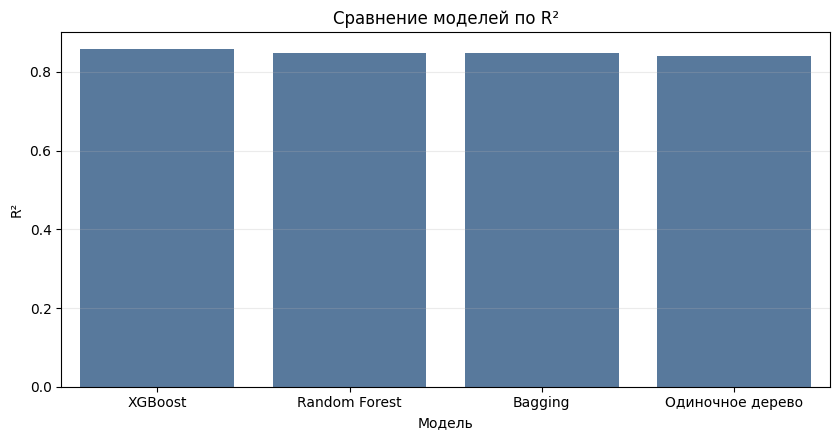

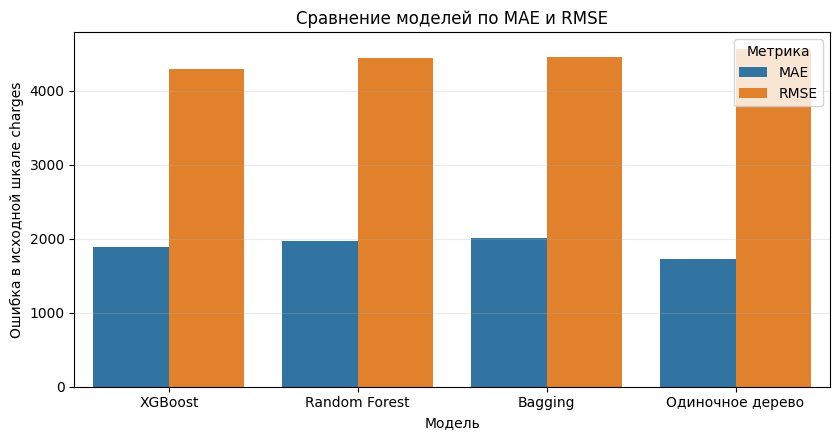

In [5]:
plt.figure(figsize=(8.5, 4.5))
sns.barplot(data=metrics_df, x='Модель', y='R2', color='#4C78A8')
plt.title('Сравнение моделей по R²')
plt.xlabel('Модель')
plt.ylabel('R²')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_r2_models.png', dpi=200, bbox_inches='tight')
plt.show()

metrics_long = metrics_df.melt(
    id_vars='Модель',
    value_vars=['MAE', 'RMSE'],
    var_name='Метрика',
    value_name='Значение'
)

plt.figure(figsize=(8.5, 4.5))
sns.barplot(data=metrics_long, x='Модель', y='Значение', hue='Метрика')
plt.title('Сравнение моделей по MAE и RMSE')
plt.xlabel('Модель')
plt.ylabel('Ошибка в исходной шкале charges')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_errors_models.png', dpi=200, bbox_inches='tight')
plt.show()

## Скорость инференса

Помимо качества важно сравнить скорость получения предсказаний.  
Измерим среднее время предсказания на тестовой выборке.

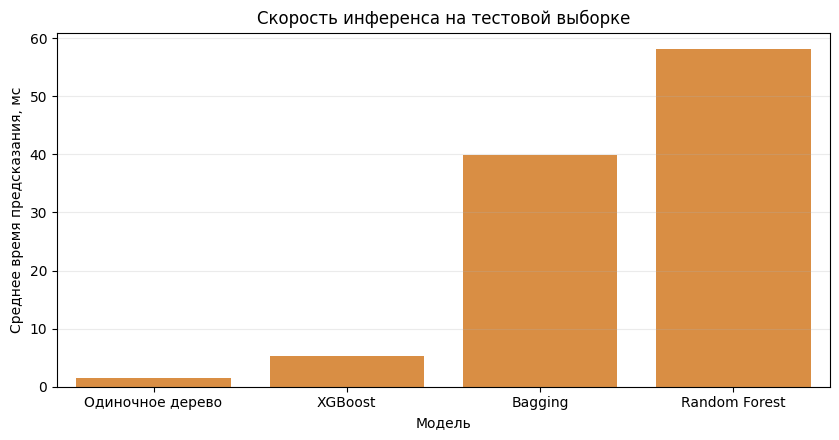

,Модель,"Среднее время, мс"
0,Одиночное дерево,1.465490
3,XGBoost,5.340938
1,Bagging,39.962050
2,Random Forest,58.071916


In [6]:
speed_rows = []
n_repeats = 50

for model_name, model in models.items():
    start = time.perf_counter()
    for _ in range(n_repeats):
        model.predict(X_test)
    elapsed = (time.perf_counter() - start) / n_repeats
    speed_rows.append({
        'Модель': model_name,
        'Среднее время, мс': elapsed * 1000
    })

speed_df = pd.DataFrame(speed_rows).sort_values(by='Среднее время, мс')
speed_df.to_csv(reports_dir / 'comparison_inference_speed.csv', index=False, encoding='utf-8')

plt.figure(figsize=(8.5, 4.5))
sns.barplot(data=speed_df, x='Модель', y='Среднее время, мс', color='#F28E2B')
plt.title('Скорость инференса на тестовой выборке')
plt.xlabel('Модель')
plt.ylabel('Среднее время предсказания, мс')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_inference_speed.png', dpi=200, bbox_inches='tight')
plt.show()

speed_df

## Графики «факт против прогноза»

Если модель предсказывает хорошо, точки должны располагаться около диагональной линии.  
Чем дальше точка от диагонали, тем больше ошибка прогноза.

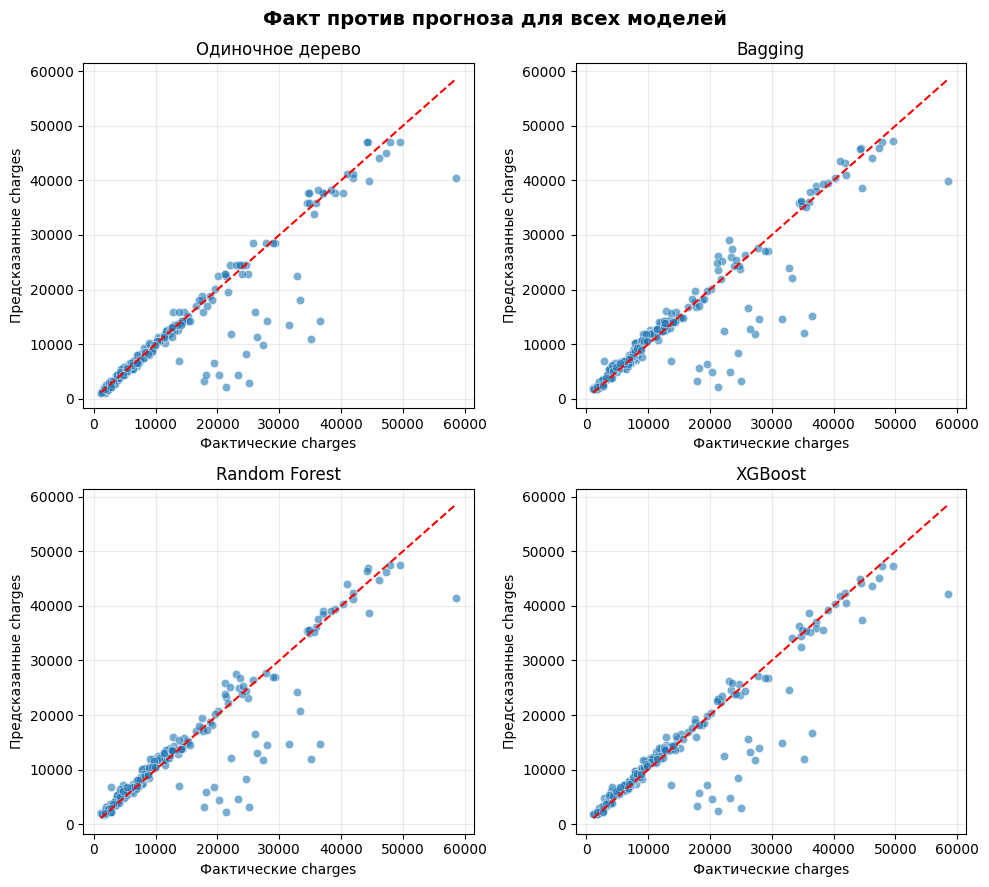

In [7]:
actual_values = inverse_target(y_test)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

min_value = actual_values.min()
max_value = actual_values.max()

for ax, (model_name, y_pred_log) in zip(axes, prediction_results.items()):
    predicted_values = inverse_target(y_pred_log)
    sns.scatterplot(x=actual_values, y=predicted_values, alpha=0.6, ax=ax)
    ax.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--')
    ax.set_title(model_name)
    ax.set_xlabel('Фактические charges')
    ax.set_ylabel('Предсказанные charges')
    ax.grid(True, alpha=0.25)

plt.suptitle('Факт против прогноза для всех моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_actual_vs_predicted_all_models.png', dpi=200, bbox_inches='tight')
plt.show()

## Анализ остатков

Остатки показывают направление и величину ошибки:

`остаток = факт - прогноз`

Если остатки имеют явную структуру, значит модель систематически ошибается на определенной области значений.

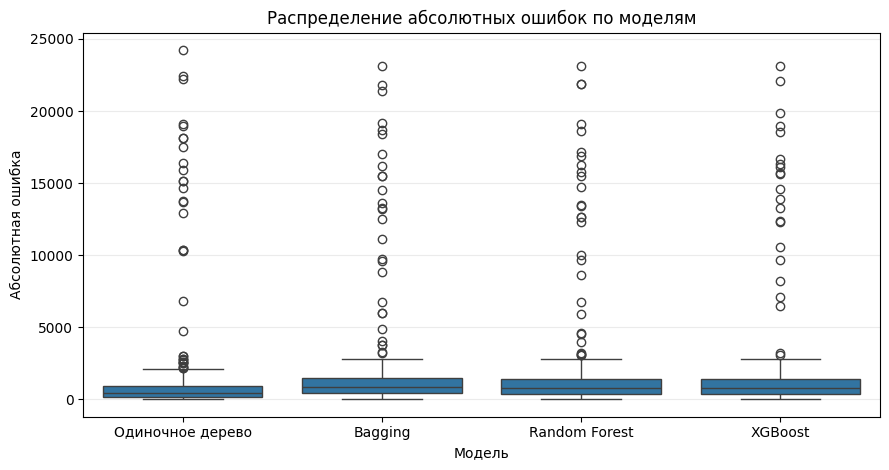

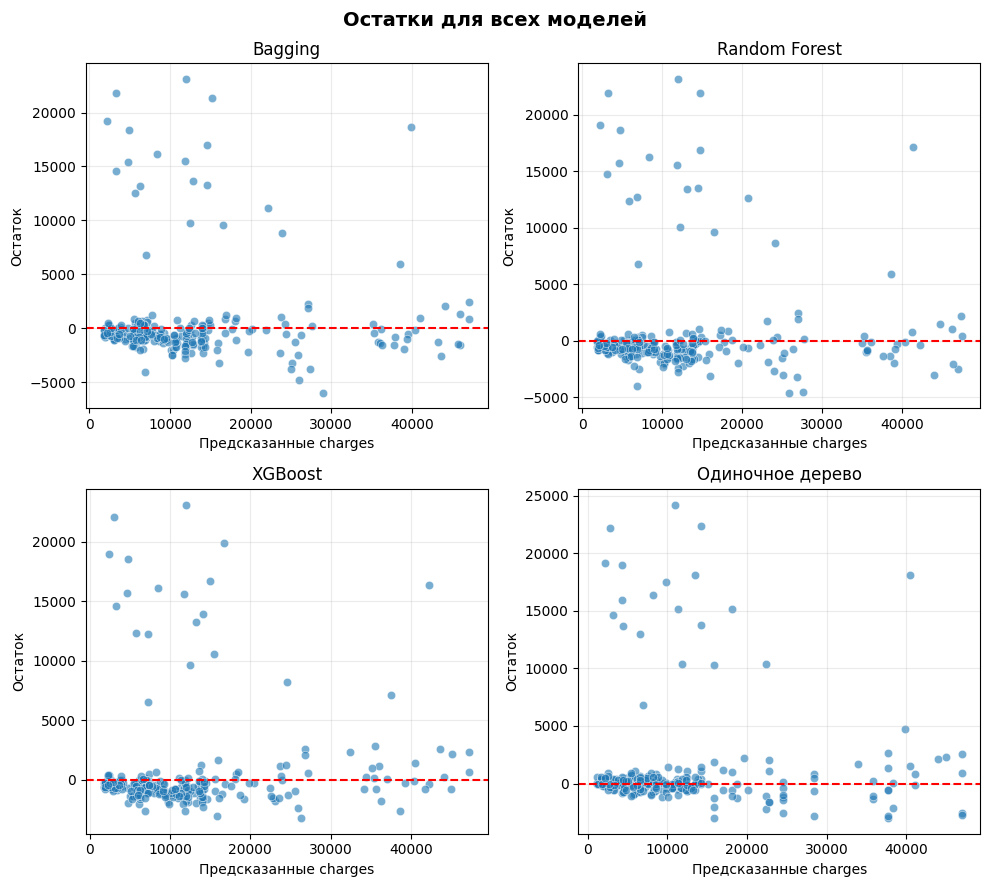

In [8]:
residual_rows = []

for model_name, y_pred_log in prediction_results.items():
    residuals = inverse_target(y_test) - inverse_target(y_pred_log)
    absolute_errors = np.abs(residuals)
    for actual, pred, residual, abs_error in zip(
        inverse_target(y_test),
        inverse_target(y_pred_log),
        residuals,
        absolute_errors
    ):
        residual_rows.append({
            'Модель': model_name,
            'Факт': actual,
            'Прогноз': pred,
            'Остаток': residual,
            'Абсолютная ошибка': abs_error
        })

residuals_df = pd.DataFrame(residual_rows)

plt.figure(figsize=(9, 4.8))
sns.boxplot(data=residuals_df, x='Модель', y='Абсолютная ошибка')
plt.title('Распределение абсолютных ошибок по моделям')
plt.xlabel('Модель')
plt.ylabel('Абсолютная ошибка')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_absolute_errors_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

for ax, (model_name, group_df) in zip(axes, residuals_df.groupby('Модель')):
    sns.scatterplot(data=group_df, x='Прогноз', y='Остаток', alpha=0.6, ax=ax)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(model_name)
    ax.set_xlabel('Предсказанные charges')
    ax.set_ylabel('Остаток')
    ax.grid(True, alpha=0.25)

plt.suptitle('Остатки для всех моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_residuals_all_models.png', dpi=200, bbox_inches='tight')
plt.show()

## Анализ ошибок по подгруппам

Проверим, не ошибаются ли модели систематически на отдельных группах:

- курящие и некурящие;
- разные диапазоны стоимости страховки.

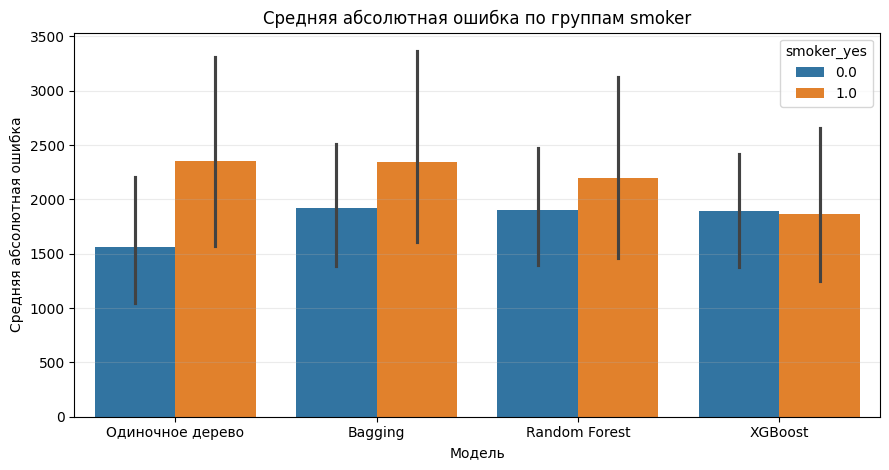

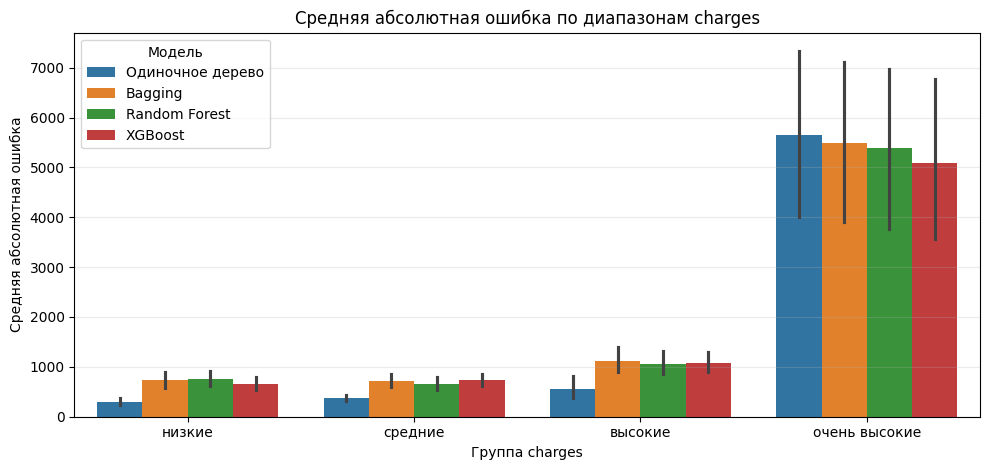

In [9]:
test_groups = test_df.copy()
test_groups['smoker_yes'] = X_test['smoker_yes']
test_groups['charges_group'] = pd.qcut(
    inverse_target(y_test),
    q=4,
    labels=['низкие', 'средние', 'высокие', 'очень высокие']
)

subgroup_rows = []

for model_name, y_pred_log in prediction_results.items():
    abs_error = np.abs(inverse_target(y_test) - inverse_target(y_pred_log))
    temp = pd.DataFrame({
        'Модель': model_name,
        'Абсолютная ошибка': abs_error,
        'smoker_yes': test_groups['smoker_yes'].values,
        'Группа charges': test_groups['charges_group'].values
    })
    subgroup_rows.append(temp)

subgroup_errors_df = pd.concat(subgroup_rows, ignore_index=True)
subgroup_errors_df.to_csv(reports_dir / 'comparison_subgroup_errors.csv', index=False, encoding='utf-8')

plt.figure(figsize=(9, 4.8))
sns.barplot(data=subgroup_errors_df, x='Модель', y='Абсолютная ошибка', hue='smoker_yes')
plt.title('Средняя абсолютная ошибка по группам smoker')
plt.xlabel('Модель')
plt.ylabel('Средняя абсолютная ошибка')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_errors_by_smoker.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 4.8))
sns.barplot(data=subgroup_errors_df, x='Группа charges', y='Абсолютная ошибка', hue='Модель')
plt.title('Средняя абсолютная ошибка по диапазонам charges')
plt.xlabel('Группа charges')
plt.ylabel('Средняя абсолютная ошибка')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_errors_by_charge_group.png', dpi=200, bbox_inches='tight')
plt.show()

## Важность признаков по моделям

Сравним встроенную важность признаков у моделей на основе деревьев.  
Для Bagging важность усредняется по базовым деревьям.

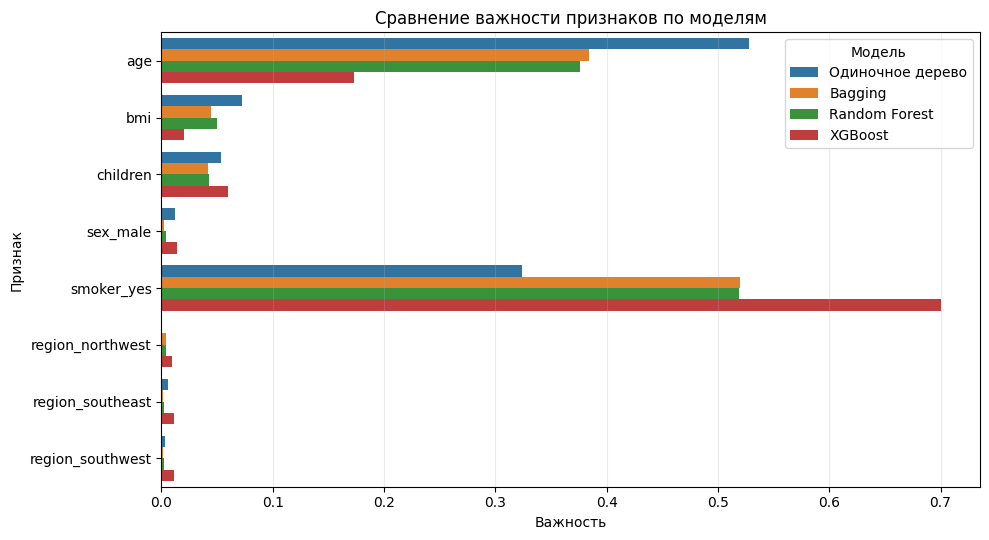

In [10]:
def bagging_feature_importance(model, feature_names):
    full_importance = np.zeros(len(feature_names))
    counts = np.zeros(len(feature_names))
    for estimator, used_features in zip(model.estimators_, model.estimators_features_):
        for local_idx, feature_idx in enumerate(used_features):
            full_importance[feature_idx] += estimator.feature_importances_[local_idx]
            counts[feature_idx] += 1
    counts[counts == 0] = 1
    return full_importance / counts


importance_rows = []

for model_name, model in models.items():
    if model_name == 'Bagging':
        importances = bagging_feature_importance(model, feature_cols)
    else:
        importances = model.feature_importances_
    for feature, importance in zip(feature_cols, importances):
        importance_rows.append({
            'Модель': model_name,
            'Признак': feature,
            'Важность': importance
        })

importance_df = pd.DataFrame(importance_rows)
importance_df.to_csv(reports_dir / 'comparison_feature_importance.csv', index=False, encoding='utf-8')

plt.figure(figsize=(10, 5.5))
sns.barplot(data=importance_df, x='Важность', y='Признак', hue='Модель')
plt.title('Сравнение важности признаков по моделям')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_feature_importance_all_models.png', dpi=200, bbox_inches='tight')
plt.show()

## SHAP-анализ

SHAP помогает интерпретировать вклад признаков в предсказания модели.

В этом разделе используем `Random Forest` как одну из лучших ансамблевых моделей.  
Сначала строим глобальный SHAP-анализ, затем смотрим локальное объяснение одного наблюдения.

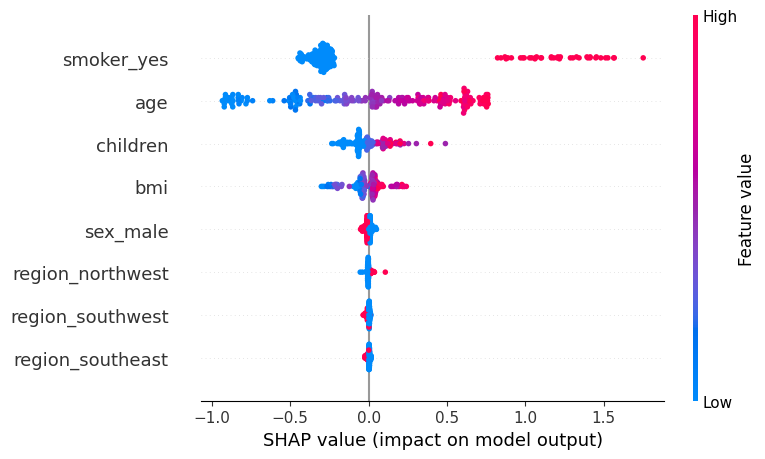

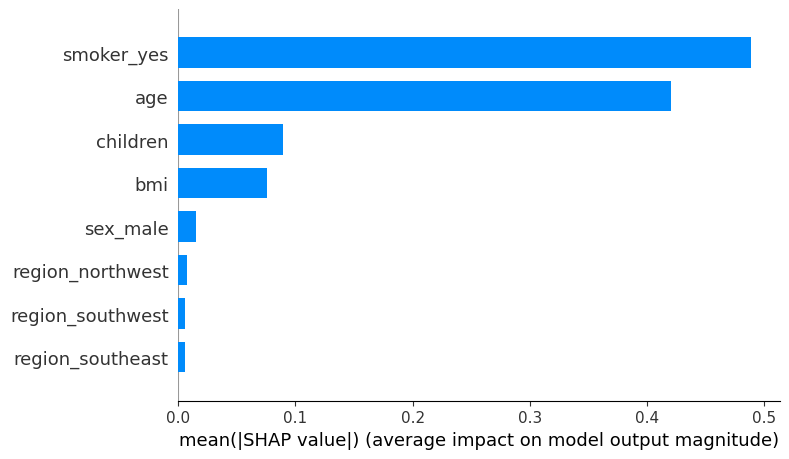

In [11]:
shap_sample = X_test.sample(n=min(200, len(X_test)), random_state=42)
rf_model = models['Random Forest']

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(shap_sample)

plt.figure()
shap.summary_plot(shap_values, shap_sample, show=False)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_shap_summary_random_forest.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_shap_bar_random_forest.png', dpi=200, bbox_inches='tight')
plt.show()

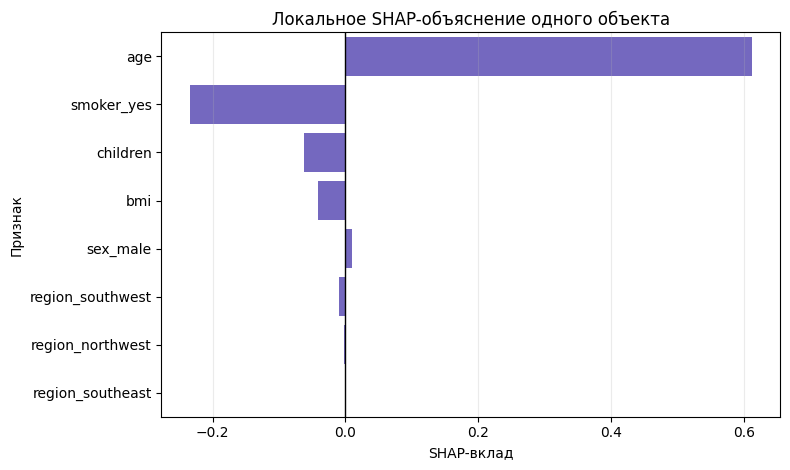

,Признак,Значение признака,SHAP-вклад
0,age,56.0,0.612295
4,smoker_yes,0.0,-0.234623
2,children,0.0,-0.062582
1,bmi,25.3,-0.041498
3,sex_male,0.0,0.009441
7,region_southwest,1.0,-0.008871
5,region_northwest,0.0,-0.001946
6,region_southeast,0.0,-0.000592


In [12]:
local_index = 0
local_features = shap_sample.iloc[[local_index]]
local_shap_values = explainer.shap_values(local_features)

local_explanation_df = pd.DataFrame({
    'Признак': local_features.columns,
    'Значение признака': local_features.iloc[0].values,
    'SHAP-вклад': local_shap_values[0]
}).sort_values(by='SHAP-вклад', key=abs, ascending=False)

plt.figure(figsize=(8, 4.8))
sns.barplot(data=local_explanation_df, x='SHAP-вклад', y='Признак', color='slateblue')
plt.axvline(0, color='black', linewidth=1)
plt.title('Локальное SHAP-объяснение одного объекта')
plt.xlabel('SHAP-вклад')
plt.ylabel('Признак')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / 'comparison_shap_local_random_forest.png', dpi=200, bbox_inches='tight')
plt.show()

local_explanation_df

## Итоговые выводы

1. `Random Forest` и `XGBoost` показывают наиболее близкие и сильные результаты по `R²` и `RMSE`.
2. `XGBoost` почти не уступает случайному лесу, но обучается и подбирается сложнее.
3. `Bagging` улучшает одиночное дерево по `R²` и `RMSE`, но не обязательно выигрывает по `MAE`.
4. Одиночное дерево остается полезной базовой моделью: оно проще и интерпретируемее, но менее устойчиво.
5. Анализ ошибок показывает, что самые сложные объекты — дорогие страховые случаи.
6. SHAP и важность признаков подтверждают ключевую роль признаков `smoker_yes`, `age` и `bmi`.